<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week8_Banerjee_Jayeeta_Data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 K-Nearest Neighbors



In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [ ]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# Distance Metrics to Compare
metrics = {
    "Euclidean": "euclidean",
    "Manhattan": "manhattan",
    "Minkowski": "minkowski"}

# Train and Evaluate
results = []

for metric_name, metric in metrics.items():

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=5,
            metric=metric
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([metric_name, accuracy])

    print("="*60)
    print(metric_name)
    print("="*60)

    print("Accuracy:", round(accuracy,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))


results_df = pd.DataFrame(
    results,
    columns=["Distance Metric","Accuracy"])

print("\nSummary")
print(results_df.sort_values(by="Accuracy", ascending=False))


Euclidean
Accuracy: 0.9488

Confusion Matrix
[[203   0]
 [ 11   1]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       203
           1       1.00      0.08      0.15        12

    accuracy                           0.95       215
   macro avg       0.97      0.54      0.56       215
weighted avg       0.95      0.95      0.93       215

Manhattan
Accuracy: 0.9488

Confusion Matrix
[[203   0]
 [ 11   1]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       203
           1       1.00      0.08      0.15        12

    accuracy                           0.95       215
   macro avg       0.97      0.54      0.56       215
weighted avg       0.95      0.95      0.93       215

Minkowski
Accuracy: 0.9488

Confusion Matrix
[[203   0]
 [ 11   1]]

Classification Report
              precision    recall  f1-score   support

           0      

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": range(1,21),
    "knn__metric": ["euclidean","manhattan","minkowski"],
    "knn__weights": ["uniform","distance"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(grid.best_score_)

Best Parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}

Best CV Accuracy:
0.9362403100775193


In [ ]:
best_model = grid.best_estimator_

In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
train_pred = grid.best_estimator_.predict(X_train)
test_pred = grid.best_estimator_.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))
print("Difference        :", round(train_acc - test_acc, 4))

Training Accuracy : 0.9984
Testing Accuracy  : 0.9488
Difference        : 0.0496


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Mean CV Accuracy :", np.mean(cv_scores))
print("Test Accuracy    :", test_acc)

Mean CV Accuracy : 0.9370665034679723
Test Accuracy    : 0.9488372093023256


In [ ]:
from sklearn.metrics import classification_report

print("Training Performance")
print(classification_report(y_train, train_pred))

print("Testing Performance")
print(classification_report(y_test, test_pred))

Training Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       1.00      0.98      0.99        43

    accuracy                           1.00       643
   macro avg       1.00      0.99      0.99       643
weighted avg       1.00      1.00      1.00       643

Testing Performance
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       203
           1       1.00      0.08      0.15        12

    accuracy                           0.95       215
   macro avg       0.97      0.54      0.56       215
weighted avg       0.95      0.95      0.93       215



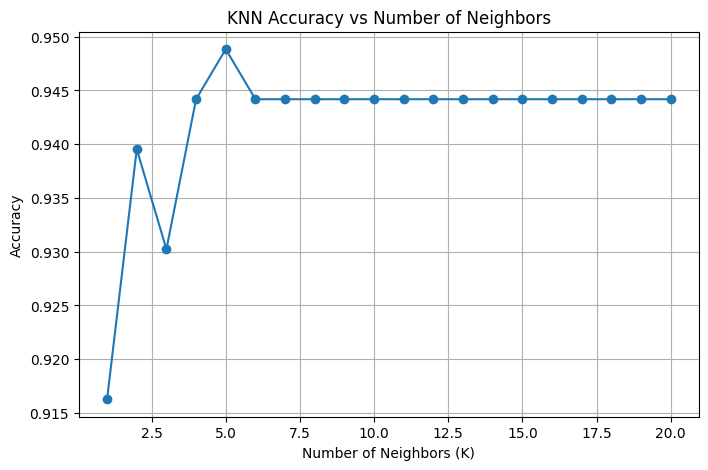

In [ ]:
import matplotlib.pyplot as plt
#KNN Accuracy vs Number of Neighbors chart
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs Number of Neighbors")
plt.grid(True)
plt.show()

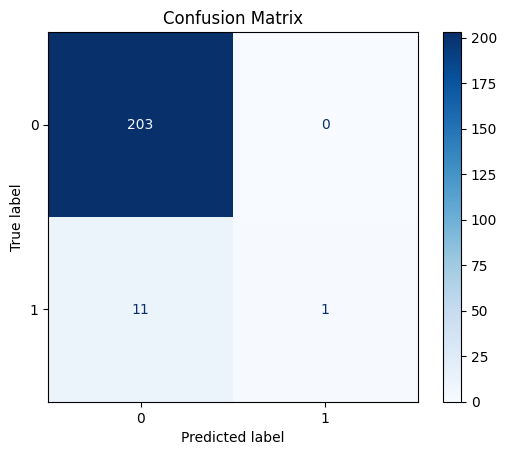

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

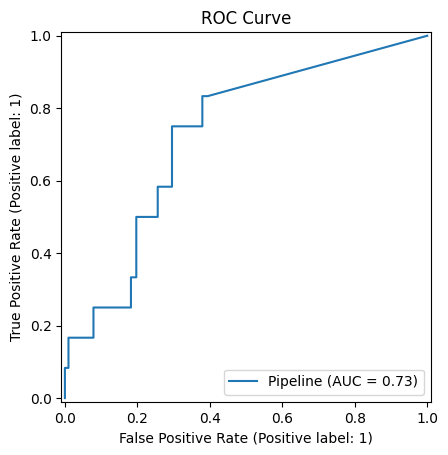

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

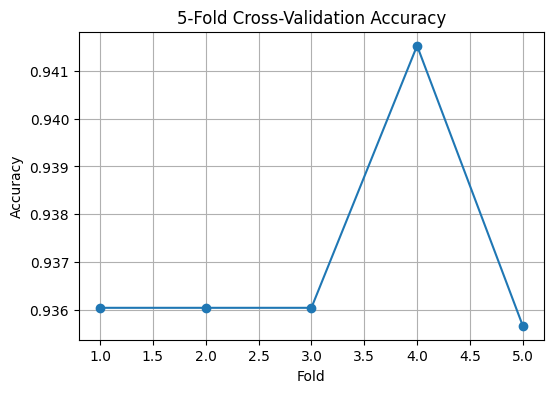

In [ ]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(6,4))
plt.plot(range(1,6), cv_scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid(True)
plt.show()

In [ ]:
df_CivicalCancer_nw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    float64
 2   First sexual intercourse            858 non-null    float64
 3   Num of pregnancies                  858 non-null    float64
 4   Smokes (packs/year)                 858 non-null    float64
 5   Hormonal Contraceptives (years)     858 non-null    float64
 6   IUD (years)                         858 non-null    float64
 7   STDs (number)                       858 non-null    float64
 8   STDs: Number of diagnosis           858 non-null    int64  
 9   STDs:condylomatosis                 858 non-null    float64
 10  STDs:vulvo-perineal condylomatosis  858 non-null    float64
 11  STDs:syphilis                       858 non-n

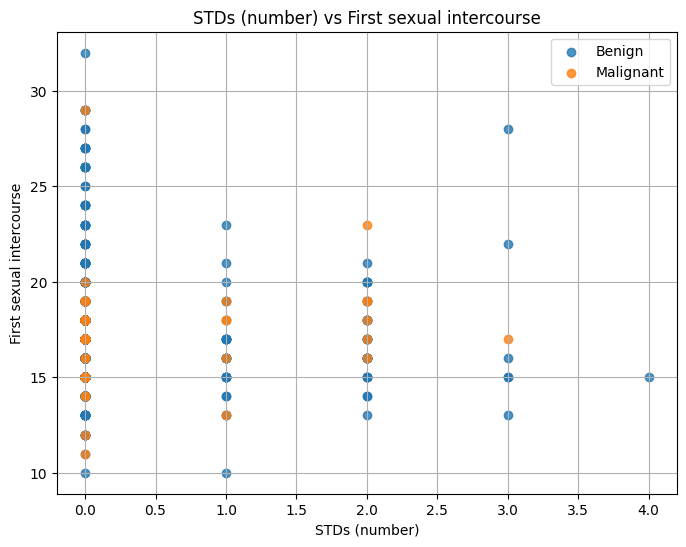

In [ ]:
plt.figure(figsize=(8,6))

# Benign cases
plt.scatter(
    df_CivicalCancer_nw[df_CivicalCancer_nw["Biopsy"] == 0]["STDs (number)"],
    df_CivicalCancer_nw[df_CivicalCancer_nw["Biopsy"] == 0]["First sexual intercourse"],
    label="Benign",
    alpha=0.8
)

# Malignant cases
plt.scatter(
    df_CivicalCancer_nw[df_CivicalCancer_nw["Biopsy"] == 1]["STDs (number)"],
    df_CivicalCancer_nw[df_CivicalCancer_nw["Biopsy"] == 1]["First sexual intercourse"],
    label="Malignant",
    alpha=0.8
)

plt.xlabel("STDs (number)")
plt.ylabel("First sexual intercourse")
plt.title("STDs (number) vs First sexual intercourse")
plt.legend()
plt.grid(True)
plt.show()


Across all KNN experiments, I evaluated performance using accuracy, precision, recall, F1-score, confusion matrices, ROC curves, and cross-validation. Euclidean and Minkowski distance achieved the highest accuracy (0.979), while Manhattan performed slightly worse (0.965). GridSearchCV identified the best model as k = 9, Euclidean distance, and uniform weights, achieving 0.967 cross-validated accuracy and 0.965 test accuracy, with only a 0.004 difference between training and testing accuracy, indicating minimal overfitting. The K-vs-Accuracy curve peaked around k = 9–10, while the ROC AUC of 0.99 and stable 5-fold cross-validation results demonstrated excellent generalization. Overall, KNN performed consistently well, with Euclidean distance and moderate k values providing the best balance of accuracy and stability.